In [12]:
import os
import json
import random
import shutil
import re
import math
import time
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from matplotlib.animation import FuncAnimation 
import multiprocessing as mp
import matplotlib as mpl

HOME = "/home/michal/slrm/gen4"
SAVE_DATA_LOCATION = "/home/michal/slrm/gen4"
if os.getenv("PLG_GROUPS_STORAGE"):
    HOME = "/net/people/plgrid/plgmichalgodek/workspace/ai-proton-simulations/gen4"
    SAVE_DATA_LOCATION =  os.environ["PLG_GROUPS_STORAGE"] + "/plggccbmc/mgodek/gen4"
os.chdir(HOME)

In [78]:
BATCH_NUM = 24

reg = re.compile(r"^_\d+$")
count_simulations = 0
for file_name in os.listdir(Path(SAVE_DATA_LOCATION,f"batch{BATCH_NUM}")):
    # print(file_name)
    if reg.match(file_name):
        count_simulations += 1


SIMULATIONS_TO_RUN = count_simulations
print(f"SIMULATIONS_TO_RUN: {SIMULATIONS_TO_RUN}")
print(f"BATCH_NUM: {BATCH_NUM}")


SIMULATIONS_TO_RUN: 24
BATCH_NUM: 24


In [79]:
import os

dir_template = f"{SAVE_DATA_LOCATION}/batch{BATCH_NUM}/_" + "{run_num}"
param_files = []

for run_num in range(SIMULATIONS_TO_RUN):
    sim_dir = dir_template.format(run_num = str(run_num))
    param_files.append(os.path.join(sim_dir,"input_params.txt"))

data_x = []

def open_energy(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)
        energy = data.get("energy")

    return float(energy)

with mp.Pool() as pool:
    data_x = pool.map(open_energy, param_files, chunksize=1)

seeds_per_energy = 0
for i,x in enumerate(data_x):
    if float(x) == data_x[0]:
        seeds_per_energy += 1
    else:
        break

print(seeds_per_energy)

2


In [80]:
dir_template = f"{SAVE_DATA_LOCATION}/batch{BATCH_NUM}/_"+"{run_num}"

z_profiles_to_convert = []
peaks_to_convert = []
print(f"looking for {SIMULATIONS_TO_RUN} directories")
for run_num in range(SIMULATIONS_TO_RUN):
    sim_dir = dir_template.format(run_num = str(run_num))
    z_profiles_to_convert.append(Path(sim_dir,"output","z_profile.bdo"))
    peaks_to_convert.append(Path(sim_dir,"output","peak.bdo"))




looking for 24 directories


In [81]:
from pymchelper.input_output import fromfile
from matplotlib import pyplot as plt
import time


start = time.time()


def load_data(filename_tuple):
    filedata_z_profile, filedata_peak = fromfile(filename_tuple[0]), fromfile(filename_tuple[1])

    return filedata_z_profile, filedata_peak


with mp.Pool() as pool:
    results = pool.map(load_data, zip(z_profiles_to_convert, peaks_to_convert), chunksize=1)

import numpy as np
data_z_dose = np.array([dataset.pages[0].data_raw for dataset in [res[0] for res in results]])
data_z_fluence_protons = np.array([dataset.pages[1].data_raw for dataset in [res[0] for res in results]])
data_z_dlet_protons = np.array([dataset.pages[4].data_raw for dataset in [res[0] for res in results]])
data_r_dose = np.array([dataset.pages[0].data_raw for dataset in [res[1] for res in results]])
data_r_fluence = np.array([dataset.pages[1].data_raw for dataset in [res[1] for res in results]])
# plt.plot(arr)
print(len(data_z_dose), data_z_dose[0].shape)
print(len(data_z_fluence_protons), data_z_fluence_protons[0].shape)
# print(len(data_dlet_protons), data_dlet_protons[0].shape)
print(len(data_r_dose), data_r_dose.shape)
print(f"time: {time.time()-start}")


24 (400,)
24 (400,)
24 (24, 100)
time: 0.6477251052856445


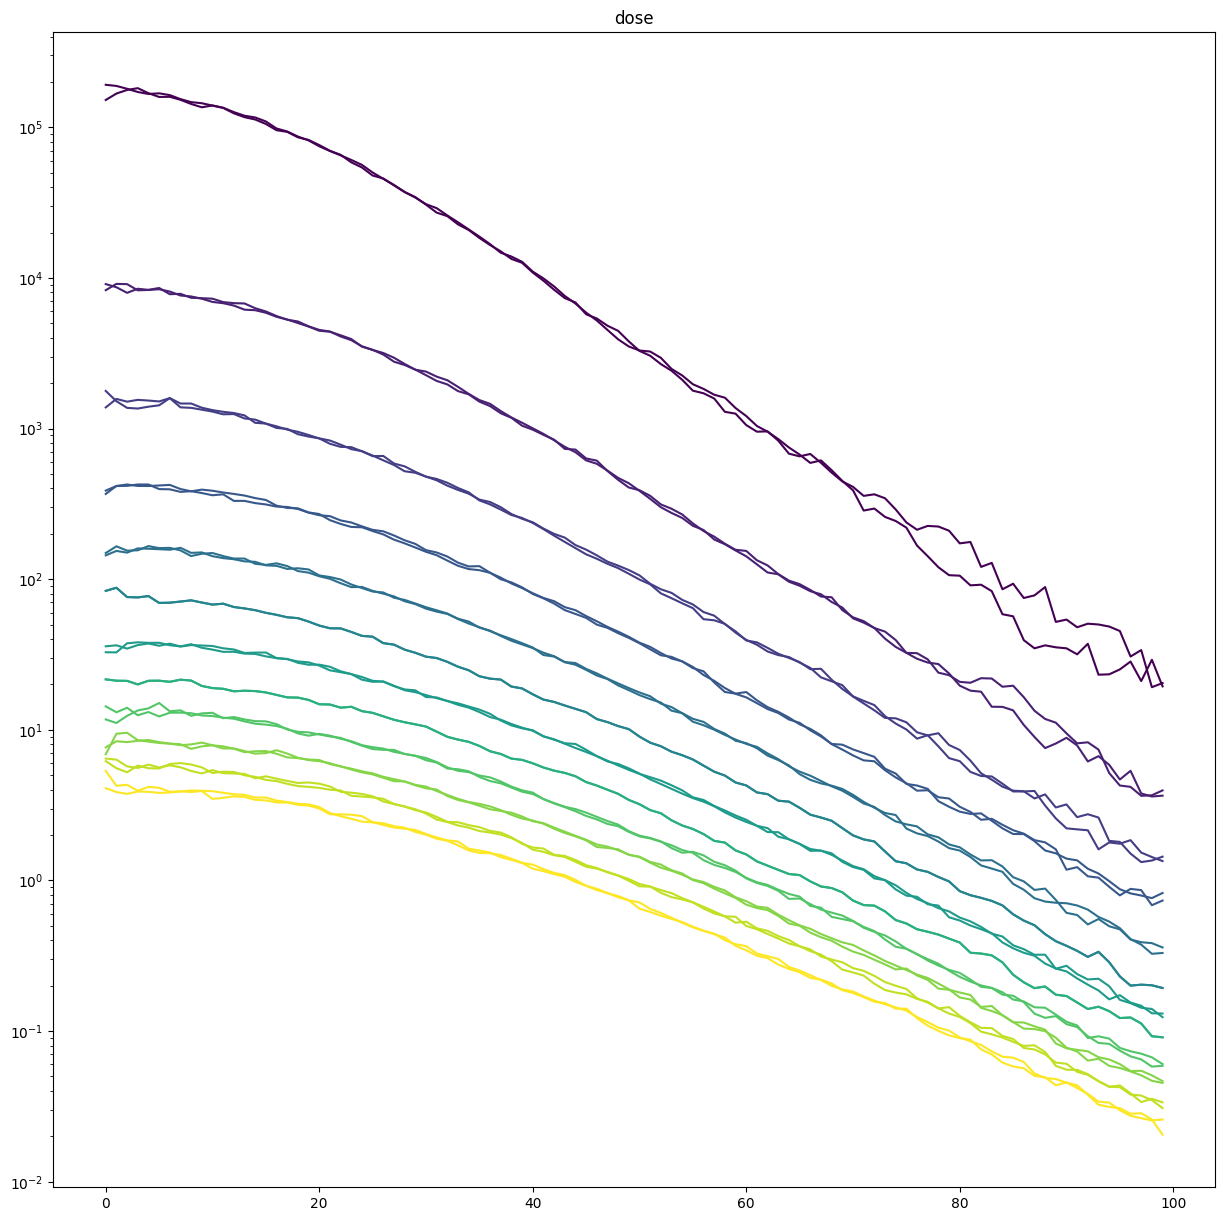

In [82]:
n_lines = len(data_r_dose)//seeds_per_energy
cmap = mpl.colormaps['viridis']           # choose any colormap you like
colors = cmap(np.linspace(0, 1, n_lines))

plt.figure(figsize=(15,15))

for i in range(len(data_r_dose)):
    plt.plot(data_r_dose[i], color=colors[i//seeds_per_energy])
    # plt.ylim(1e0, 1e5)
plt.yscale("log")
plt.title("dose")
plt.show()

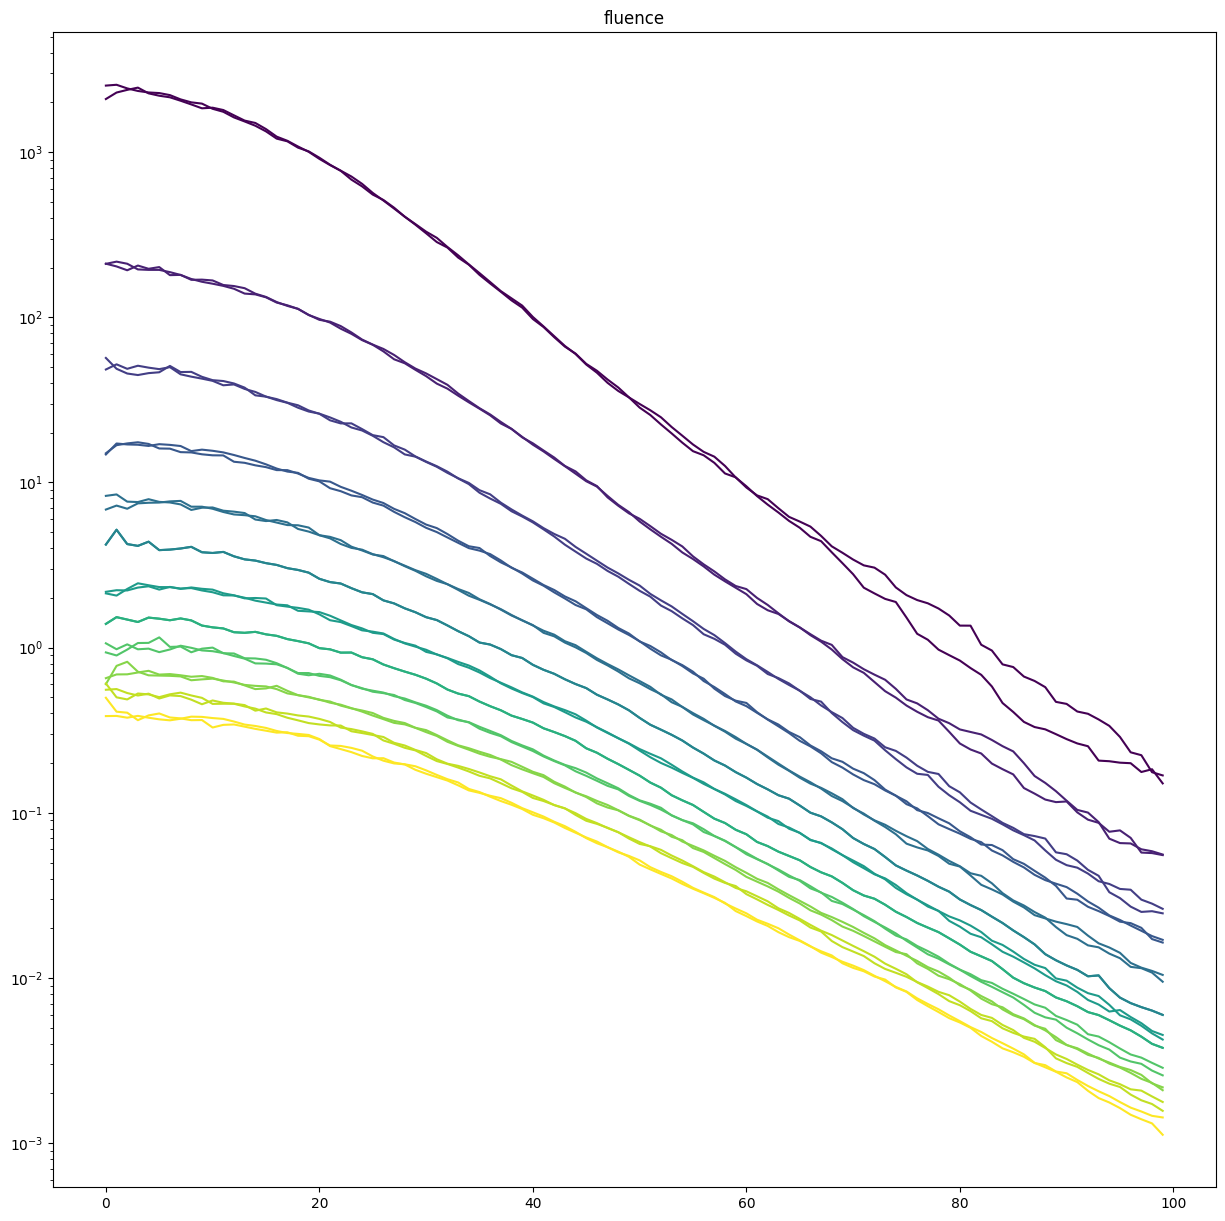

In [83]:
n_lines = len(data_r_fluence)//seeds_per_energy
cmap = mpl.colormaps['viridis']           # choose any colormap you like
colors = cmap(np.linspace(0, 1, n_lines))

plt.figure(figsize=(15,15))

for i in range(len(data_r_fluence)):
    plt.plot(data_r_fluence[i], color=colors[i//seeds_per_energy])
    # plt.ylim(0, 1e1)
plt.yscale("log")
plt.title("fluence")
plt.show()